In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost fastapi uvicorn jupyter

In [3]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('../data/flight_data.csv')

# ── Basic Info ──────────────────────────────────────
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (300153, 12)

Column Names:
 ['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']

Data Types:
 Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object

First 5 rows:


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [5]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [6]:
print("Price range: ₹", df['price'].min(), "to ₹", df['price'].max())
print("Average price: ₹", round(df['price'].mean(), 2))

Price range: ₹ 1105 to ₹ 123071
Average price: ₹ 20889.66


/Users/imamuddin/Desktop/ML-Projects/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


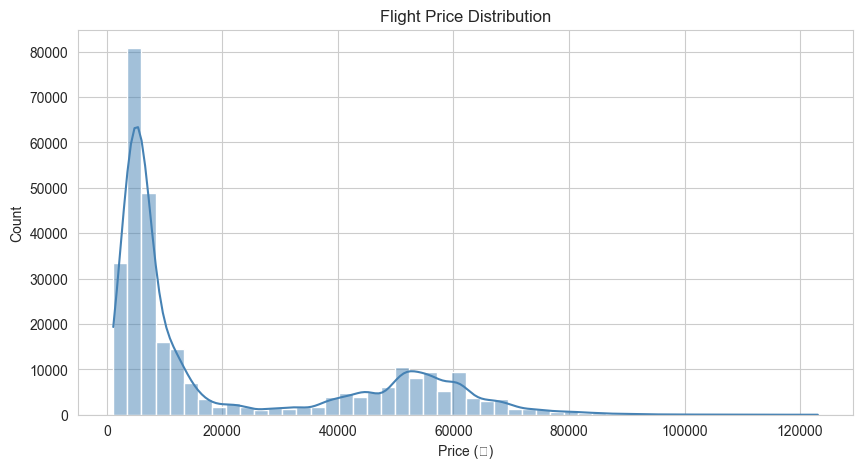

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='steelblue')
plt.title('Flight Price Distribution')
plt.xlabel('Price (₹)')
plt.ylabel('Count')
plt.show()

/var/folders/dr/wqpltt2s4fj6t5m2xm66ynbh0000gn/T/ipykernel_29698/155737585.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='airline', y='price', palette='Set2')


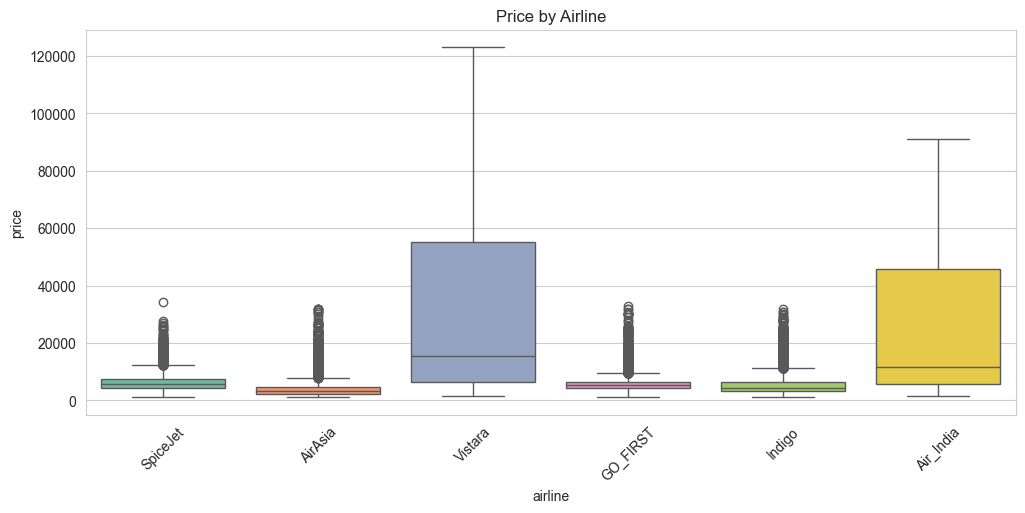

In [8]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='airline', y='price', palette='Set2')
plt.xticks(rotation=45)
plt.title('Price by Airline')
plt.show()

/var/folders/dr/wqpltt2s4fj6t5m2xm66ynbh0000gn/T/ipykernel_29698/2237151932.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stops', y='price', palette='Set3')


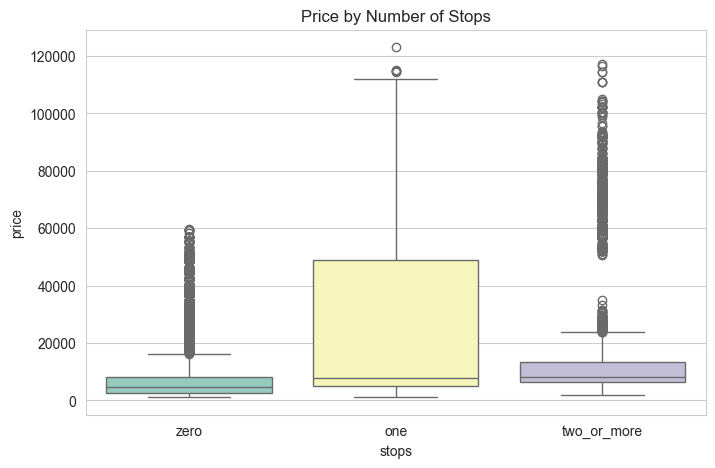

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='stops', y='price', palette='Set3')
plt.title('Price by Number of Stops')
plt.show()

/Users/imamuddin/Desktop/ML-Projects/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


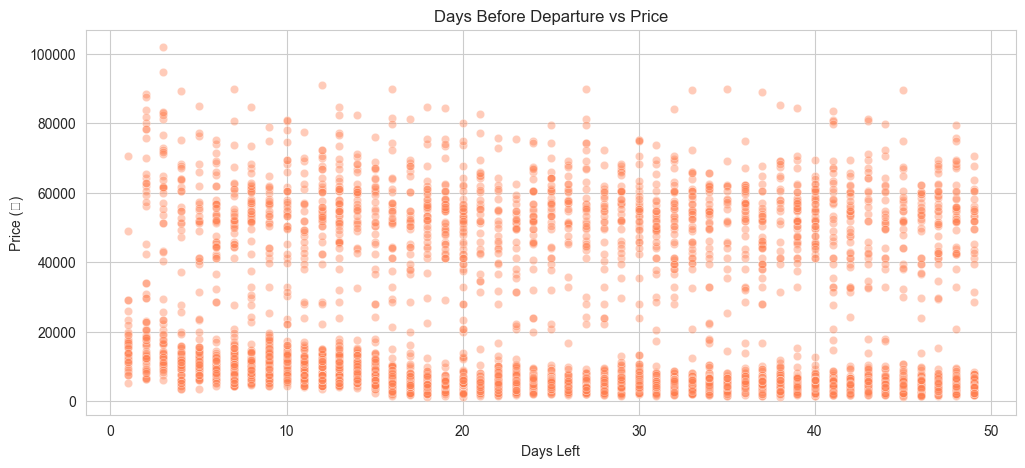

In [10]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df.sample(5000), x='days_left', y='price', 
                alpha=0.4, color='coral')
plt.title('Days Before Departure vs Price')
plt.xlabel('Days Left')
plt.ylabel('Price (₹)')
plt.show()

/var/folders/dr/wqpltt2s4fj6t5m2xm66ynbh0000gn/T/ipykernel_29698/287956394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='departure_time', y='price', palette='coolwarm')


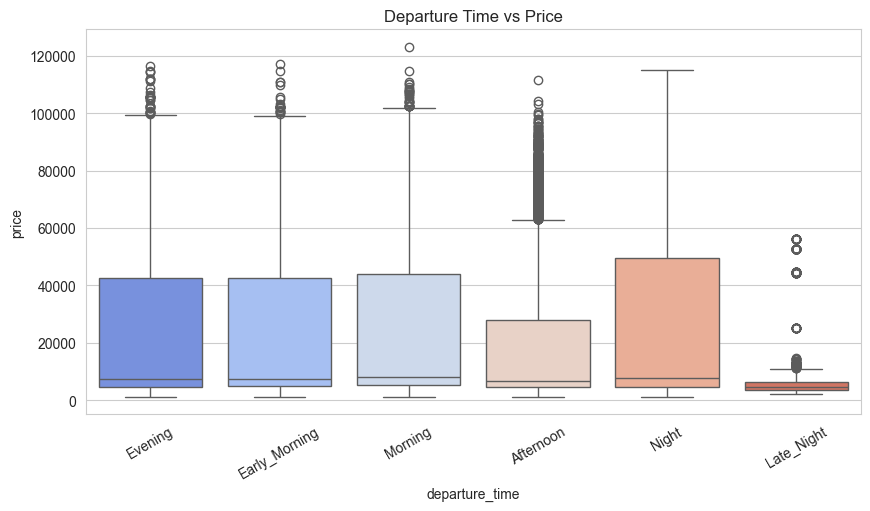

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='departure_time', y='price', palette='coolwarm')
plt.title('Departure Time vs Price')
plt.xticks(rotation=30)
plt.show()

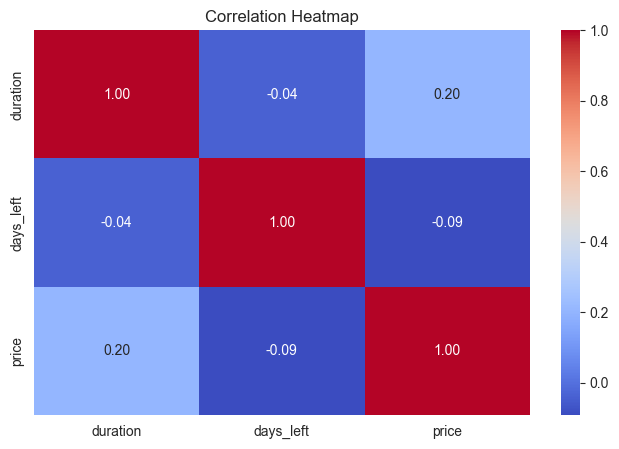

In [12]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[['duration', 'days_left', 'price']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
categorical_cols = ['airline', 'source_city', 'destination_city', 
                    'stops', 'class', 'departure_time', 'arrival_time']

for col in categorical_cols:
    print(f"\n── {col} ──")
    print(df[col].value_counts())


── airline ──
airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

── source_city ──
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

── destination_city ──
destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

── stops ──
stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

── class ──
class
Economy     206666
Business     93487
Name: count, dtype: int64

── departure_time ──
departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

── arrival_time ──
arrival_time
Night            91538
Evening          78323
Morni